In [1]:
# If running in Colab uncomment the next line to install packages
# !pip install --quiet torch torchvision torchaudio scikit-learn timm
print('Ensure PyTorch + torchvision are installed (Colab: uncomment install).')

Ensure PyTorch + torchvision are installed (Colab: uncomment install).


In [3]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import transforms, datasets, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print('Imports done')

Imports done


In [4]:
# Data Curation
kaggle_credentials = json.load(open("kaggle.json"))

In [5]:
# setup kaggle API key as environment variables
os.environ["KAGGLE_USERNAME"] = kaggle_credentials["username"]
os.environ["KAGGLE_KEY"] = kaggle_credentials["key"]

In [6]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset
!unzip plantvillage-dataset.zip -d plantvillage


Streaming output truncated to the last 5000 lines.
  inflating: plantvillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e345153-aed9-4879-a2cc-24f9dc5100e7___UF.GRC_YLCV_Lab 01798_final_masked.jpg  
  inflating: plantvillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e37e8ad-3944-4e11-bc10-dd82616274d7___YLCV_NREC 2915_final_masked.jpg  
  inflating: plantvillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e382244-fb3a-4caa-af71-05fff25f1c27___UF.GRC_YLCV_Lab 03397_final_masked.jpg  
  inflating: plantvillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e3b9886-ce13-49d5-8f80-ccf4e5ddbeac___YLCV_GCREC 5479_final_masked.jpg  
  inflating: plantvillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e615038-7a87-446a-a2cd-f76c5c75b6dd___YLCV_GCREC 5144_final_masked.jpg  
  inflating: plantvillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Cur

In [7]:
print(os.listdir("plantvillage/plantvillage dataset"))

print(len(os.listdir("plantvillage/plantvillage dataset/segmented")))
print(os.listdir("plantvillage/plantvillage dataset/segmented")[:5])

print(len(os.listdir("plantvillage/plantvillage dataset/color")))
print(os.listdir("plantvillage/plantvillage dataset/color")[:5])

print(len(os.listdir("plantvillage/plantvillage dataset/grayscale")))
print(os.listdir("plantvillage/plantvillage dataset/grayscale")[:5])

['color', 'segmented', 'grayscale']
38
['Raspberry___healthy', 'Corn_(maize)___healthy', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Apple___Cedar_apple_rust', 'Squash___Powdery_mildew']
38
['Raspberry___healthy', 'Corn_(maize)___healthy', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Apple___Cedar_apple_rust', 'Squash___Powdery_mildew']
38
['Raspberry___healthy', 'Corn_(maize)___healthy', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Apple___Cedar_apple_rust', 'Squash___Powdery_mildew']


(256, 256, 3)


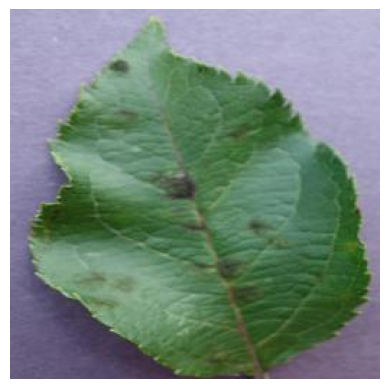

In [8]:
image_path = "/content/plantvillage/plantvillage dataset/color/Apple___Apple_scab/00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG"

img = mpimg.imread(image_path)

print(img.shape)

#display of image
plt.imshow(img)
plt.axis("off")
plt.show()

In [9]:
DATA_DIR = '/content/plantvillage/plantvillage dataset/color'  # change to color/grayscale/segmented
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 12
VAL_SPLIT = 0.15
SEED = 42
LR = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 4
NUM_WORKERS = 4
MODEL_NAME = 'resnet50'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [10]:
if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(f"DATA_DIR not found: {DATA_DIR}")

print(os.listdir(DATA_DIR)[:20])

full_dataset = datasets.ImageFolder(DATA_DIR)
print('Total images found:', len(full_dataset))
print('Classes:', full_dataset.classes[:20])

['Raspberry___healthy', 'Corn_(maize)___healthy', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Apple___Cedar_apple_rust', 'Squash___Powdery_mildew', 'Tomato___healthy', 'Grape___Black_rot', 'Pepper,_bell___Bacterial_spot', 'Peach___healthy', 'Cherry_(including_sour)___healthy', 'Potato___Late_blight', 'Corn_(maize)___Common_rust_', 'Tomato___Target_Spot', 'Blueberry___healthy', 'Apple___healthy', 'Strawberry___Leaf_scorch', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Peach___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus']
Total images found: 54305
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black

In [11]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(25),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1
    ),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


full = datasets.ImageFolder(DATA_DIR)
indices = list(range(len(full)))
targets = np.array(full.targets)
train_idx, val_idx = train_test_split(indices, test_size=VAL_SPLIT,
                                      stratify=targets, random_state=SEED)
print('Train images:', len(train_idx), 'Val images:', len(val_idx))

train_ds = Subset(datasets.ImageFolder(DATA_DIR, transform=train_transform), train_idx)
val_ds = Subset(datasets.ImageFolder(DATA_DIR, transform=val_transform), val_idx)

class_to_idx = full.class_to_idx
idx_to_class = {v:k for k,v in class_to_idx.items()}
num_classes = len(class_to_idx)
print('Num classes:', num_classes)

Train images: 46159 Val images: 8146
Num classes: 38


In [12]:
train_labels = [full.targets[i] for i in train_idx]
class_counts = np.bincount(train_labels, minlength=num_classes)
print('Class counts (train):', class_counts)
class_weights = 1.0 / (class_counts + 1e-8)
sample_weights = [class_weights[y] for y in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print('Batches:', len(train_loader), len(val_loader))

Class counts (train): [ 536  528  234 1398 1277  894  726  436 1013  837  988 1003 1176  915
  360 4681 1952  306  847 1256  850  850  129  315 4326 1560  943  388
 1808  850 1623  809 1505 1425 1193 4553  317 1352]
Batches: 1443 255


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [13]:
def build_resnet(num_classes, model_name='resnet50', pretrained=True, in_channels=3):
    if model_name=='resnet18':
        model = models.resnet18(pretrained=pretrained)
    else:
        model = models.resnet50(pretrained=pretrained)
    if in_channels!=3:
        w = model.conv1.weight.data
        new_conv = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if in_channels==1:
            new_conv.weight.data = w.mean(dim=1, keepdim=True)
        else:
            new_conv.weight.data = w[:, :in_channels, :, :].clone()
        model.conv1 = new_conv
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(num_ftrs,512), nn.ReLU(inplace=True), nn.Dropout(0.4), nn.Linear(512, num_classes))
    return model

example_path = full.samples[0][0]
example_img = Image.open(example_path)
in_channels = 3 if example_img.mode=='RGB' else 1
print('Example img mode:', example_img.mode)

model = build_resnet(num_classes=num_classes, model_name=MODEL_NAME, pretrained=True, in_channels=in_channels).to(device)
print('Model ready')

# Freeze backbone (improves generalization)
for name, param in model.named_parameters():
    if not name.startswith("fc"):
        param.requires_grad = False


Example img mode: RGB


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 174MB/s]


Model ready


In [14]:
ce_class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(
    weight=ce_class_weights,
    label_smoothing=0.1
)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)
scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):

    # Unfreeze deeper layers after initial epochs
    if epoch == 4:
     print("Unfreezing layer4 and fc...")
    for name, param in model.named_parameters():
        if "layer4" in name or "fc" in name:
            param.requires_grad = True

    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0
    from tqdm import tqdm
    for imgs, labels in tqdm(train_loader, desc=f'Train {epoch+1}'):
        imgs = imgs.to(device); labels = labels.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=(scaler is not None)):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        if scaler is not None:
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        else:
            loss.backward(); optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        running_corrects += (preds==labels).sum().item()
        total += imgs.size(0)
    train_loss = running_loss/total; train_acc = running_corrects/total

    # validation
    model.eval(); val_loss=0.0; val_correct=0; val_total=0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device); labels = labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds==labels).sum().item()
            val_total += imgs.size(0)
    val_loss = val_loss/val_total; val_acc = val_correct/val_total

    history['train_loss'].append(train_loss); history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss); history['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1}/{NUM_EPOCHS} - train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f} | val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}')
    scheduler.step(val_loss)

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss; epochs_no_improve = 0
        torch.save({'model_state': model.state_dict(), 'idx_to_class': idx_to_class}, 'best_model.pt')
        print('Saved best_model.pt')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print('Early stopping')
            break

print('Training done')

/tmp/ipython-input-557696182.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
Train 1:   0%|          | 0/1443 [00:00<?, ?it/s]/tmp/ipython-input-557696182.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):
Train 1: 100%|██████████| 1443/1443 [05:44<00:00,  4.19it/s]


Epoch 1/12 - train_loss: 1.0712, train_acc: 0.7786 | val_loss: 1.2763, val_acc: 0.9380
Saved best_model.pt


Train 2: 100%|██████████| 1443/1443 [05:48<00:00,  4.14it/s]


Epoch 2/12 - train_loss: 0.7846, train_acc: 0.9357 | val_loss: 1.1652, val_acc: 0.9633
Saved best_model.pt


Train 3: 100%|██████████| 1443/1443 [05:48<00:00,  4.14it/s]


...

Epoch 10/12 - train_loss: 0.6958, train_acc: 0.9791 | val_loss: 1.1021, val_acc: 0.9827
Saved best_model.pt


Train 11: 100%|██████████| 1443/1443 [05:39<00:00,  4.25it/s]


Epoch 11/12 - train_loss: 0.6886, train_acc: 0.9803 | val_loss: 1.0916, val_acc: 0.9869
Saved best_model.pt


Train 12: 100%|██████████| 1443/1443 [05:41<00:00,  4.23it/s]


Epoch 12/12 - train_loss: 0.6847, train_acc: 0.9812 | val_loss: 1.0900, val_acc: 0.9893
Saved best_model.pt
Training done


                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      1.00      0.99        94
                                 Apple___Black_rot       1.00      1.00      1.00        93
                          Apple___Cedar_apple_rust       0.98      1.00      0.99        41
                                   Apple___healthy       1.00      0.99      0.99       247
                               Blueberry___healthy       1.00      1.00      1.00       225
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      1.00       158
                 Cherry_(including_sour)___healthy       0.98      1.00      0.99       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.87      0.96      0.91        77
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       179
               Corn_(maize)___Northern_Leaf_Blight       0.98      0.93      0.

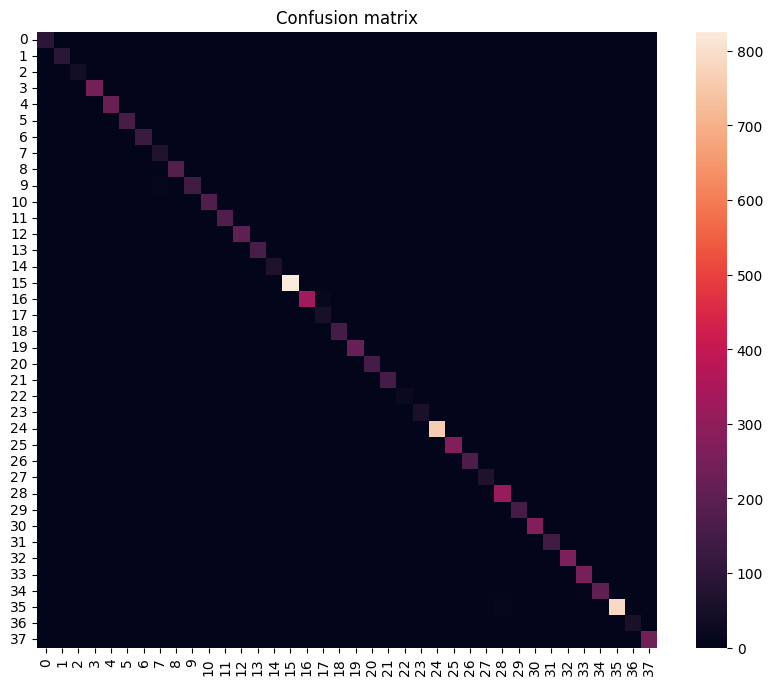

In [15]:
ckpt = torch.load('best_model.pt', map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()

all_preds=[]; all_labels=[]
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs=imgs.to(device); labels=labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy().tolist()); all_labels.extend(labels.cpu().numpy().tolist())

print(classification_report(all_labels, all_preds, target_names=[idx_to_class[i] for i in range(num_classes)], zero_division=0))

import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8)); sns.heatmap(cm, annot=False); plt.title('Confusion matrix'); plt.show()


In [16]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='weighted'
)

print(f"Accuracy: {acc:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-score (weighted): {f1:.4f}")


Accuracy: 0.9893
Precision (weighted): 0.9899
Recall (weighted): 0.9893
F1-score (weighted): 0.9894


In [17]:
top3_correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs)
        _, top3 = outputs.topk(3, dim=1)
        top3_correct += top3.eq(labels.view(-1,1)).any(dim=1).sum().item()
        total += labels.size(0)

top3_acc = top3_correct / total
print(f"Top-3 Accuracy: {top3_acc:.4f}")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Top-3 Accuracy: 0.9989


In [18]:
import torch.nn.functional as F

def predict_topk(model, image_path, transform, idx_to_class, device, topk=3):
    img = Image.open(image_path).convert('RGB' if in_channels==3 else 'L')
    x = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(x); probs = F.softmax(logits, dim=1)
        top_probs, top_idx = probs.topk(topk, dim=1)
    top_probs = top_probs.cpu().numpy().squeeze(); top_idx = top_idx.cpu().numpy().squeeze()
    return [(idx_to_class[int(i)], float(p)) for i,p in zip(np.atleast_1d(top_idx), np.atleast_1d(top_probs))]

# quick test
sample = full.samples[0][0]
print('Top preds:', predict_topk(model, sample, val_transform, idx_to_class, device, topk=5))


Top preds: [('Apple___Apple_scab', 0.9471225738525391), ('Potato___healthy', 0.007062144577503204), ('Apple___Cedar_apple_rust', 0.005997026804834604), ('Peach___healthy', 0.003338465467095375), ('Raspberry___healthy', 0.0028836035635322332)]



Predicted disease categories:
Grape___Esca_(Black_Measles): 0.8308
Potato___healthy: 0.0250
Peach___healthy: 0.0133


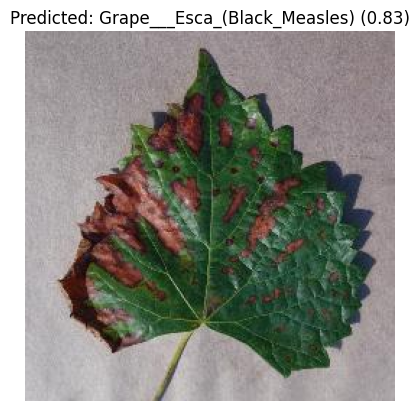

In [19]:
# Example: Prediction on a custom image
custom_image_path = "/content/plantvillage/plantvillage dataset/color/Grape___Esca_(Black_Measles)/01162551-b800-4df8-ac46-64d17d6ac5bf___FAM_B.Msls 1153.JPG"

# Run prediction
predictions = predict_topk(model, custom_image_path, val_transform, idx_to_class, device, topk=3)

# Show results
print("\nPredicted disease categories:")
for cls, prob in predictions:
    print(f"{cls}: {prob:.4f}")

# Show image with the top prediction as title
import matplotlib.pyplot as plt
img = Image.open(custom_image_path)
plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {predictions[0][0]} ({predictions[0][1]:.2f})")
plt.show()



Predicted disease categories:
Corn_(maize)___Common_rust_: 0.8903
Potato___healthy: 0.0203
Apple___Cedar_apple_rust: 0.0090


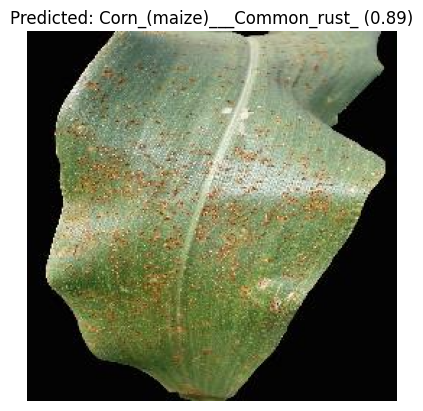

In [20]:
# Example: Prediction on a custom image
custom_image_path = "/content/plantvillage/plantvillage dataset/color/Corn_(maize)___Common_rust_/RS_Rust 1566.JPG"

# Run prediction
predictions = predict_topk(model, custom_image_path, val_transform, idx_to_class, device, topk=3)

# Show results
print("\nPredicted disease categories:")
for cls, prob in predictions:
    print(f"{cls}: {prob:.4f}")

# Show image with the top prediction as title
import matplotlib.pyplot as plt
img = Image.open(custom_image_path)
plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {predictions[0][0]} ({predictions[0][1]:.2f})")
plt.show()


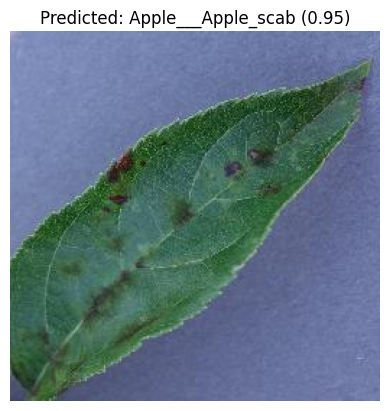

In [21]:
folder_path = "/content/plantvillage/plantvillage dataset/color/Apple___Apple_scab"
image_files = os.listdir(folder_path)
random_image = random.choice(image_files)
custom_image_path = os.path.join(folder_path, random_image)

# Run prediction
predictions = predict_topk(model, custom_image_path, val_transform, idx_to_class, device, topk=3)

# Show image and prediction
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(custom_image_path)
plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {predictions[0][0]} ({predictions[0][1]:.2f})")
plt.show()


In [29]:
!python app.py

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://99fd3fbd142b2bede3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
Keyboard interruption in main thread... closing server.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 3043, in block_thread
    time.sleep(0.1)
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/content/app.py", line 84, in <module>
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2950, in launch
    self.block_thread()
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 3047, in block_thread
    self.server.close()
  File "/usr/local/lib/python3.12/dist-packages/gradio/http_server.py", lin

In [26]:
ckpt = torch.load("best_model.pt", map_location="cpu")
for k in ckpt["model_state"].keys():
    if k.startswith("layer4"):
        print("This is ResNet50")
        break


This is ResNet50


In [23]:
ckpt = torch.load("best_model.pt", map_location="cpu")

for k in ckpt['model_state'].keys():
    if k.startswith("fc"):
        print(k)


fc.1.weight
fc.1.bias
fc.4.weight
fc.4.bias
